<h1>The White Wine Dataset</h1>

The white wine data is available in 
<a> https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv </a>

In [ ]:
import sys
import os

# Get the project root (one level above wine_quality)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)


In [1]:
import pandas as pd
from logger import get_logger

logger = get_logger(__name__)

logger.debug("Logging verified")

white_wine_df = pd.read_csv("data/winequality-white.csv", sep=";")

DEBUG: Logging verified


In [2]:
white_wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
white_wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [4]:
white_wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

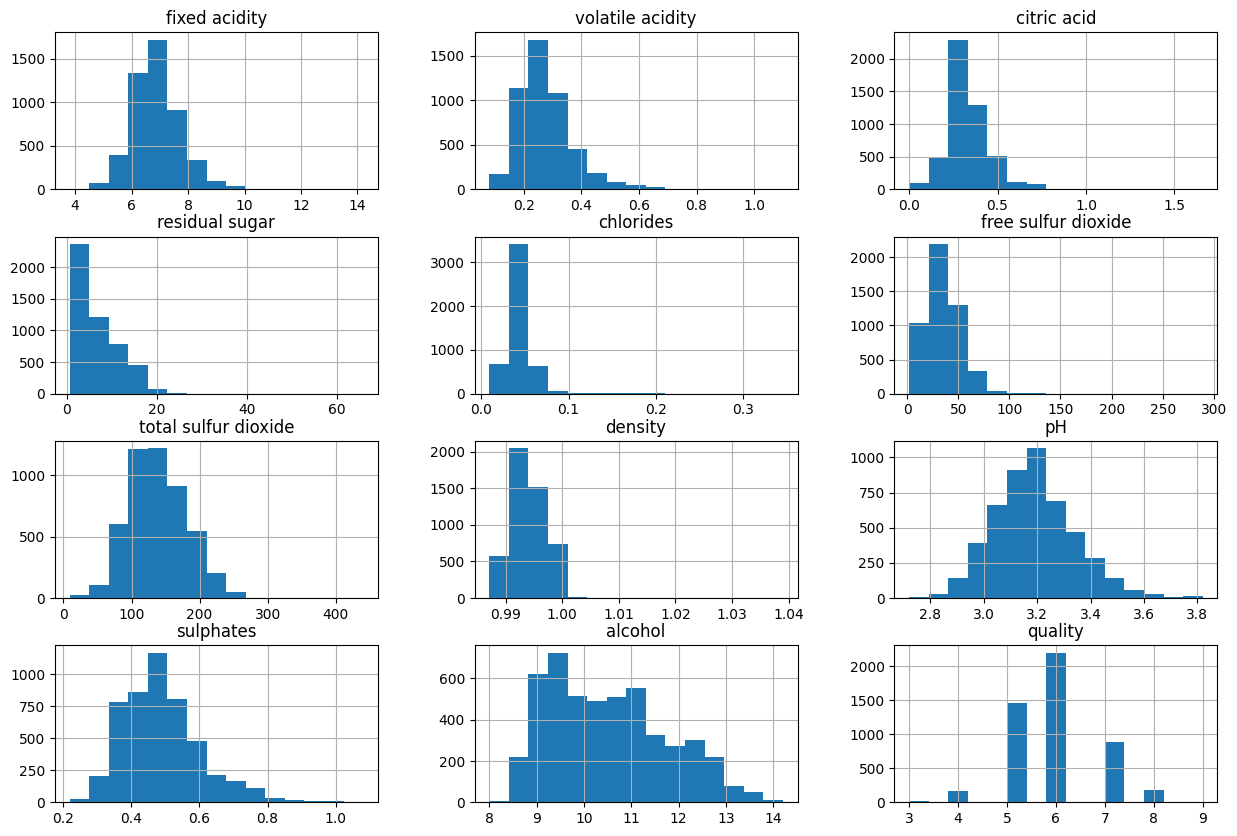

In [5]:
white_wine_df.hist(bins = 15, figsize=(15,10))

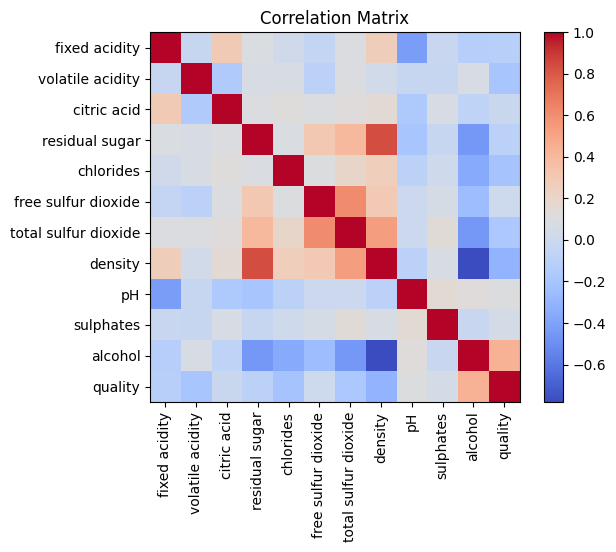

In [6]:
from utils.evaluation_metrics import plot_correlation_matrix

plot_correlation_matrix(white_wine_df)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

x = white_wine_df.drop('quality', axis=1)
y = white_wine_df['quality']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), x.columns)
    ]
)

x_train_preprocessed = preprocessing_pipeline.fit_transform(x_train)
x_test_preprocessed = preprocessing_pipeline.transform(x_test)

le = LabelEncoder()

y_train_preprocessed = le.fit_transform(y_train)
y_test_preprocessed = le.transform(y_test)

logger.info("Data preprocessing completed. The code has applied only StandardScaler to all the columns as every columns are numerical.")

INFO: Data preprocessing completed. The code has applied only StandardScaler to all the columns as every columns are numerical.


In [8]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

logger.info(f"Using device: {device}")

INFO: Using device: cuda


In [9]:
x_train_tensor = torch.tensor(x_train_preprocessed, dtype=torch.float)
y_train_tensor = torch.tensor(y_train_preprocessed, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_preprocessed, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test_preprocessed, dtype=torch.long).to(device)

# these create a new tensor from the data provided

In [10]:
from torch import nn
from torch import Tensor

class WhiteWineQualityModel_0(nn.Module):
    r"""
        This class is a simple feed forward neural network for the white wine quality data.
    """
    def __init__(
            self, 
            input_dim: int, 
            output_dim: int
        ) -> None:
        r"""
        Initialize the model architecture (constructor)
    
        Args:
            input_dim (int) -> Number of input features (columns)
            output_dim (int) -> Number of output classes

        Returns:
            None
        """
        
        super().__init__()

        self.input_layer = nn.Linear(in_features=input_dim, out_features=33) # we have 11 features and 1 label. We are taking 3 times the input features as hidden units 
        self.hidden_layer_1 = nn.Linear(in_features=33, out_features=33)
        self.hidden_layer_2 = nn.Linear(in_features=33, out_features=33)
        self.hidden_layer_3 = nn.Linear(in_features=33, out_features=33)
        self.output_layer = nn.Linear(in_features=33, out_features=output_dim) # output layer will have 6 unit for the final 1 label.
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(p=0)

    def forward(
            self, 
            x: Tensor
        ) -> Tensor:
        r""" 
        holds the forward pass logic
        
        Args :
            x (torch.Tensor) -> input feature tensor

        Returns:
            torch.Tensor -> Predicted logits (raw scores) for each other
        """
        
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)

        return x
    

2026-01-25 14:26:01,327	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-25 14:26:01,434	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
INFO: Epoch : 0 
	Train Loss : 1.6471732989434273 
	Test Loss : 1.3376792669296265 
	Accuracy : 0.44081631302833557

INFO: Epoch : 10 
	Train Loss : 1.0384719640977922 
	Test Loss : 1.0766708850860596 
	Accuracy : 0.5377550721168518

INFO: Epoch : 20 
	Train Loss : 0.9867125768815318 
	Test Loss : 1.0421301126480103 
	Accuracy : 0.5377550721168518

INFO: Epoch : 30 
	Train Loss : 0.9542240711950487 
	Test Loss : 1.0377635955810547 
	Accuracy : 0.559183657169342

INFO: Epoch : 40 
	Train Loss : 0.9237968383296844 
	Test Loss : 1.037729263305664 
	Accuracy : 0.5714285373687744

INFO: Epoch : 50 
	Train Loss : 0.9015770419951408 
	Test Loss : 1.0432100296

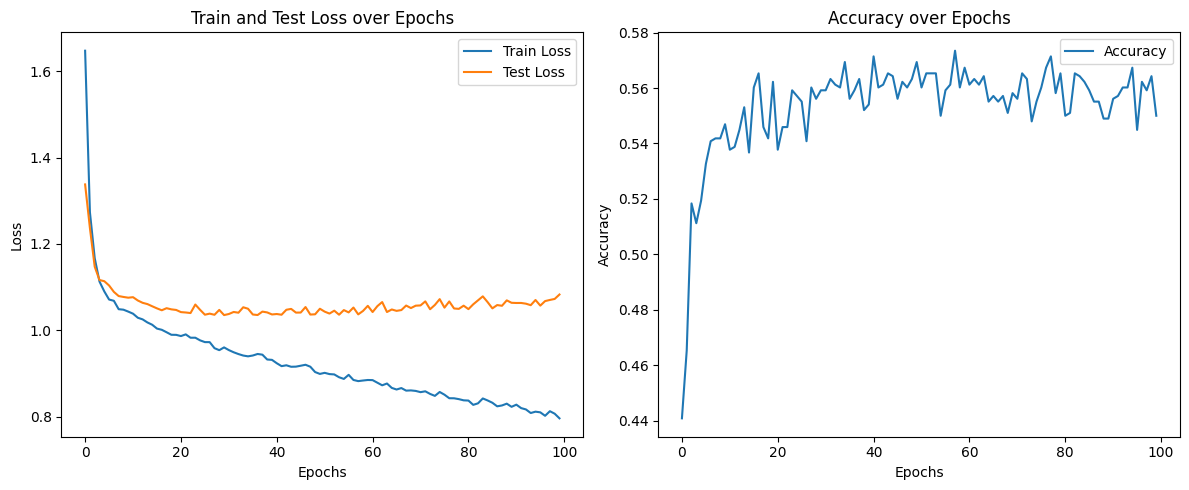

INFO: Training completed. Best accuracy achieved: 0.573469340801239


In [11]:
r"""
Training the model and logging the training parameters and evaluation metrics to `wine_quality/results`
Plotting 
"""

from utils.training_utils import train_dataset_v0

model_0 = WhiteWineQualityModel_0(input_dim=11, output_dim=7).to(device)

epochs = 100
lr = 0.001
optimizer = torch.optim.Adam(model_0.parameters(), lr = lr)
loss_fn = nn.CrossEntropyLoss()

logs_filename = "results/white_wine_quality_results.csv"
trained_model, best_accuracy = train_dataset_v0(model= model_0,
                 x_train_tensor=x_train_tensor,
                 y_train_tensor=y_train_tensor,
                 x_test_tensor=x_test_tensor,
                 y_test_tensor=y_test_tensor,
                 optimizer=optimizer,
                 loss_function=loss_fn,
                 epochs=epochs,
                 device=device,
                 log_file=logs_filename,
                 batch_size=64)

logger.info(f"Training completed. Best accuracy achieved: {best_accuracy}")

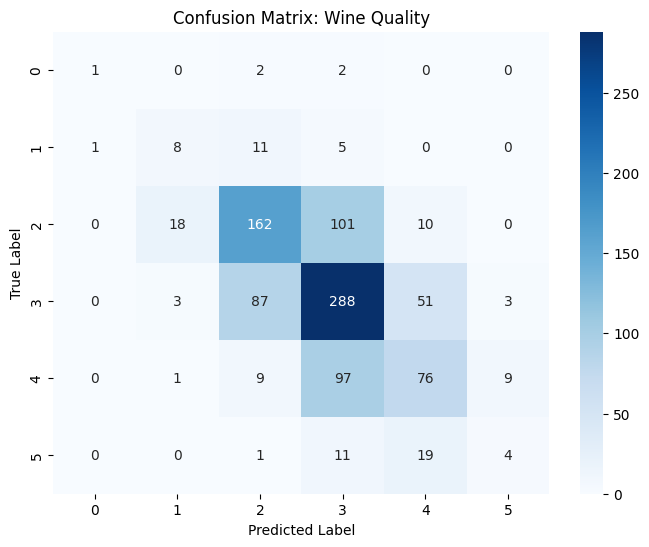

In [12]:
from utils.evaluation_metrics import plot_confusion_matrix

trained_model.eval()

with torch.inference_mode():
    y_logits = trained_model(x_test_tensor)
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

plot_confusion_matrix(y_test_tensor, y_preds)

In [13]:
accuracy = (y_preds == y_test_tensor).sum().item() / len(y_test_tensor)
logger.info(f"Test Accuracy: {accuracy * 100:.2f}%")

INFO: Test Accuracy: 55.00%


In [28]:
class CustomModel(nn.Module):

    def __init__(self, input_dim, output_dim, hidden_layers, dropout, activation ):
        super().__init__()

        # if len(hidden_layers) != len(dropout):
        #     raise Exception("Please give dropouts list of length qual to that of hidden layers. \nGive a probability of 0 to exlclude dropout in specific layer.")
        layers = []
        prev_dim = input_dim

        for index in range(len(hidden_layers)):
            layers.append(nn.Linear(prev_dim,hidden_layers[index]))
            layers.append(activation())
            layers.append(nn.Dropout(p=dropout))
            prev_dim = hidden_layers[index]

        layers.append(nn.Linear(prev_dim,output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [29]:
print(CustomModel(
    input_dim=11,
    output_dim=7,
    hidden_layers=[22,33,44,33,22],
    dropout=0.2,
    activation=nn.GELU
    )
    )

CustomModel(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=22, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=22, out_features=33, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=33, out_features=44, bias=True)
    (7): GELU(approximate='none')
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=44, out_features=33, bias=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=33, out_features=22, bias=True)
    (13): GELU(approximate='none')
    (14): Dropout(p=0.2, inplace=False)
    (15): Linear(in_features=22, out_features=7, bias=True)
  )
)


In [38]:
del ray_tune_wrapper

In [39]:
"""
Tune is a Python library for experiment execution and hyperparameter tuning at any scale.
We are tuning with the learning rate, batch size, optimizer and epochs - any other hyperparameters shall be added if needed

the below tuner can be used if entire process shall be processed in cpu itself, if gpu computation is needed we need to add with_reources function to the tuner

the code for separating tasks to both cpu and gpu or gpu only is commented in the next cell 
"""

import torch.optim as optim
from ray.tune import with_parameters, with_resources
from ray import tune, train
from utils.training_utils import ray_tune_wrapper
import os

current_project_path = os.getcwd()
os.makedirs("white_wine_ray_tune_results",exist_ok=True)
custom_storage_path = os.path.join(current_project_path,"white_wine_ray_tune_results")

tuning_model_class = CustomModel

# search_space = {
#     "lr" : tune.loguniform(1e-5,1e-1),
#     "batch_size" : tune.choice([16,32,64,128]),
#     "optimizer" : tune.choice([optim.Adam, optim.SGD, optim.NAdam, optim.Adadelta, optim.RMSprop, optim.Adadelta, optim.Adagrad]),
#     "epochs" : tune.choice([100, 300, 500, 700]),
#     "dropout" : tune.choice([0, 0.1, 0.2, 0.4])
# }

search_space = {
    "lr": tune.loguniform(1e-5, 1e-0),
    "batch_size": 64,
    "optimizer": tune.choice([optim.NAdam ]),
    "epochs": tune.choice([500]),
    "hidden_layers": tune.choice([[33, 44, 33], [33, 44, 7],[22]*6 ]),
    "dropout": tune.choice([0]),
    "activation": tune.choice([nn.LeakyReLU, nn.Tanh])
}


tuner = tune.Tuner(
    with_parameters(
        ray_tune_wrapper,
        model_class=tuning_model_class,
        x_train_tensor=x_train_tensor.cpu(),
        y_train_tensor=y_train_tensor.cpu(),
        x_test_tensor=x_test_tensor.cpu(),
        y_test_tensor=y_test_tensor.cpu(),
        input_dim = 11,
        output_dim = 7
    ),
    param_space=search_space,
    tune_config= tune.TuneConfig(
        metric = "accuracy",
        mode = "max",
        num_samples = 30
    ),
    run_config= tune.RunConfig(
        name="wine_quality_experiment",
        storage_path=custom_storage_path,
        verbose =1
    )
)

results = tuner.fit()
best_results = results.get_best_result(metric= "accuracy", mode="max")
logger.info(f"Best Config : { best_results.config }")

df = results.get_dataframe()
path ="results/white_wine_tuning_results.csv"

if  not os.path.exists(os.path.dirname(path)):
    os.makedirs(os.path.dirname(path))
df.to_csv(path,mode = 'a', index=True , header=not os.path.isfile(path))

(ray_tune_wrapper pid=115678) INFO: device : cpu
(ray_tune_wrapper pid=115678) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/diwakar/IIT/pytorch_mini_projects/wine_quality/white_wine_ray_tune_results/wine_quality_experiment/ray_tune_wrapper_f8697_00007_7_activation=ref_ph_bcab2133,dropout=0,epochs=500,hidden_layers=33_44_33,lr=0.0016,optimizer=ref_ph_7_2026-01-25_17-15-50/checkpoint_000000)
(ray_tune_wrapper pid=115664) INFO: device : cpu [repeated 19x across cluster]
(ray_tune_wrapper pid=115679) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/diwakar/IIT/pytorch_mini_projects/wine_quality/white_wine_ray_tune_results/wine_quality_experiment/ray_tune_wrapper_f8697_00006_6_activation=ref_ph_8cecdf80,dropout=0,epochs=500,hidden_layers=33_44_33,lr=0.0001,optimizer=ref_ph_7_2026-01-25_17-15-50/checkpoint_000038) [repeated 712x across cluster]
(ray_tune_wrapper pid=115665) Checkpoint successfully created at: Checkpoint(filesystem=loc

By narrowing down the hyperparameters, we achieved a maximum accuracy of 64 percent. For this feedforward neural network (FNN) with its limited architecture, the best model reached 64 percent accuracy. The architecture consisted of an input dimension of 11 neurons, an output dimension of 7 neurons, and three hidden layers — 33 neurons in the first layer, 44 in the second, and 33 in the third — with no dropout and LeakyReLU/ReLU activations.

Hyperparameter tuning was not fully exhaustive; further improvements could be explored by customizing parameters for optimizers or activations, experimenting with more complex architectures such as stacking networks, or applying alternative loss functions after preprocessing the data and building simpler regression/classifier models as baselines.

In [ ]:
best_result = results.get_best_result(metric="accuracy", mode="max")
checkpoint_path = os.path.join(best_result.checkpoint.path, "checkpoint.pt") 
model_state = torch.load(checkpoint_path)["model_state"]

In [65]:
best_model = CustomModel(
    input_dim = 11,
    output_dim = 7,
    hidden_layers = [33, 44, 33],
    dropout = 0,
    activation = nn.LeakyReLU
)

best_model.load_state_dict(model_state)
best_model.eval()

CustomModel(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=33, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0, inplace=False)
    (3): Linear(in_features=33, out_features=44, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0, inplace=False)
    (6): Linear(in_features=44, out_features=33, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Dropout(p=0, inplace=False)
    (9): Linear(in_features=33, out_features=7, bias=True)
  )
)

In [62]:
from utils.evaluation_metrics import accuracy

with torch.inference_mode():
    best_model.to("cuda")
    x_preds_tensor = best_model(Tensor(x_test_tensor.to("cuda")))
    y_test_tensor.to("cuda")
    accuracy_obtained = accuracy(x_preds_tensor, y_test_tensor)
    print(accuracy_obtained) 

0.636734664440155


In [ ]:
torch.save(best_model.state_dict(), "results/best_model.pth")

# best_model = CustomModel(
#     input_dim = 11,
#     output_dim = 7,
#     hidden_layers = [33, 44, 33],
#     dropout = 0,
#     activation = nn.LeakyReLU
# ) ## rebuild the same best model and load the state dictionary from the path

In [ ]:
# tuner = tune.Tuner(
#     with_resources(
#         with_parameters(
#             ray_tune_wrapper,
#             model_class=tuning_model_class,
#             x_train_tensor=x_train_tensor,
#             y_train_tensor=y_train_tensor,
#             x_test_tensor=x_test_tensor,
#             y_test_tensor=y_test_tensor,
#         ),
#         resources = {"cpu" : 2 , "gpu" : 1}
#     ),
#     param_space=search_space,
#     tune_config= tune.TuneConfig(
#         metric = "accuracy",
#         mode = "max",
#         num_samples = 10
#     ),
#     run_config= tune.RunConfig(
#         name="wine_quality_experiment",
#         storage_path=custom_storage_path,
#         verbose =1
#     )
# )